# NGHIÊN CỨU DỰ BÁO XÁC SUẤT VỠ NỢ THẺ TÍN DỤNG QUA MÔ HÌNH HỒI QUY LOGISTIC THUẦN TÚY
## BÁO CÁO THỰC NGHIỆM VÀ QUY TRÌNH HỌC MÁY BƯỚC CHUẨN HỌC THUẬT

---

### Tóm tắt nghiên cứu (Executive Abstract)

Nghiên cứu này trình bày một quy trình thực nghiệm học máy toàn diện nhằm giải quyết bài toán dự báo rủi ro vỡ nợ thẻ tín dụng (*Credit Card Default Prediction*). Dữ liệu được trích xuất từ nghiên cứu thực nghiệm của Yeh & Lien (2009) tại Đài Loan bao gồm 30,000 khách hàng với 23 biến độc lập. 

Nhằm bảo đảm tính minh bạch toán học tuyệt đối và tuân thủ các chuẩn mực khắt khe của học máy ứng dụng:
1. **Kiến trúc mô hình hóa thuần túy (Zero-Library Dependency):** Toàn bộ thuật toán Hồi quy Logistic, cơ chế điều chuẩn L1 (Lasso) / L2 (Ridge), giải thuật tối ưu hóa Gradient Descent theo mẻ, các lớp tiền xử lý chuẩn hóa đặc trưng (Z-Score Standardization), cơ chế chia tách tập mẫu Stratified Split, ma trận kiểm định chéo K-Fold và toàn bộ hệ thống thang đo đánh giá đều được lập trình hoàn toàn bằng thư viện ma trận số học nguyên bản `NumPy` và `Pandas`, không phụ thuộc vào `scikit-learn`.
2. **Bảo toàn tính chân thực của dữ liệu (Zero Synthetic Data):** Dự án kiên quyết bác bỏ các phương pháp sinh mẫu nhân tạo (như SMOTE hay nội suy điểm ảo) để bảo vệ toàn vẹn phân phối xác suất đồng thời $P(\mathbf{x}, y)$ của thị trường tài chính thực tế.
3. **Kiểm soát rò rỉ dữ liệu tuyệt đối (Zero Data Leakage Protocol):** Tham số chuẩn hóa được ước lượng độc lập và nghiêm ngặt bên trong từng phân vùng huấn luyện.
4. **Cấu trúc 21 bước rành mạch:** Tiến trình nghiên cứu được chia làm 21 giai đoạn tuần tự, bao quát trọn vẹn từ định nghĩa bài toán, phân tích lý thuyết mất mát, điều chuẩn, tối ưu hóa siêu tham số đến kiểm định ngưỡng kinh doanh.


In [ ]:
# ====================================================================
# KHỞI TẠO MÔI TRƯỜNG VÀ NẠP CÁC MÔ-ĐUN THUẦN NUMPY
# Không sử dụng scikit-learn trong bất kỳ giai đoạn mô hình hóa nào
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model import (
    StandardScaler, train_test_split,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    LogisticRegression, StratifiedKFold, GridSearchCV
)

print("Môi trường thực nghiệm đã sẵn sàng. Toàn bộ thuật toán vận hành trên nền tảng NumPy thuần túy.")


ModuleNotFoundError: No module named 'numpy'

: 

## Bước 1: Xác định bài toán (Problem Definition)

### 1.1. Bối cảnh nghiệp vụ tài chính

Trong hoạt động ngân hàng thương mại hiện đại, việc quản trị rủi ro tín dụng cá nhân giữ vai trò sống còn trong việc đảm bảo tỷ lệ an toàn vốn (Capital Adequacy Ratio) theo các hiệp ước Basel II và Basel III. Khi một khách hàng phát sinh nợ xấu (*default*), tổ chức tín dụng phải trích lập dự phòng rủi ro và gánh chịu tổn thất trực tiếp lên vốn chủ sở hữu.

### 1.2. Định dạng bài toán học máy

- **Không gian mục tiêu:** Dự báo biến phụ thuộc nhị phân $y \in \{0, 1\}$, trong đó $y = 1$ đại diện cho biến cố khách hàng vỡ nợ (không thanh toán nghĩa vụ nợ tối thiểu trong kỳ kế tiếp), và $y = 0$ là khách hàng hoàn thành nghĩa vụ tài chính đúng hạn.
- **Không gian đầu vào:** Tập véc-tơ quan sát $d$-chiều $\mathbf{x} \in \mathbb{R}^{23}$ bao gồm thông tin hạn mức cấp tín dụng, biến nhân khẩu học (giới tính, học vấn, tình trạng hôn nhân, độ tuổi), lịch sử trạng thái trả nợ qua 6 tháng liên tiếp (`PAY_0` đến `PAY_6`), dư nợ sao kê từng tháng (`BILL_AMT1` đến `BILL_AMT6`), và số tiền thực trả (`PAY_AMT1` đến `PAY_AMT6`).
- **Bản chất tổn thất phi đối xứng (Asymmetric Loss Nature):** Sai lầm loại II (False Negative - dự báo người sắp vỡ nợ là an toàn và tiếp tục cấp tín dụng) gây thiệt hại kinh tế nghiêm trọng hơn gấp nhiều lần so với sai lầm loại I (False Positive - từ chối phục vụ một khách hàng có khả năng trả nợ tốt). Do đó, mục tiêu học máy không dừng lại ở độ chính xác tổng thể mà là tối đa hóa độ nhạy (*Recall*) và giá trị cân hòa $F_1$-Score.


In [ ]:
# Khởi tạo ma trận chi phí sai lầm phi đối xứng (Asymmetric Cost Matrix)
# Giả định tổn thất khi bỏ sót 1 khoản nợ xấu (False Negative) = 10,000 USD
# Chi phí thẩm định bổ sung khi cảnh báo nhầm (False Positive) = 500 USD
cost_fn = 10000  # Cost of False Negative (Nợ xấu bị bỏ lọt)
cost_fp = 500    # Cost of False Positive (Cảnh báo nhầm)

print("=== ĐẶC THÙ NGHIỆP VỤ BÀI TOÁN QUẢN TRỊ RỦI RO TÍN DỤNG ===")
print(f"Tổn thất trực tiếp khi bỏ sót nợ xấu (False Negative): {cost_fn:,} USD")
print(f"Chi phí vận hành khi cảnh báo nhầm (False Positive):  {cost_fp:,} USD")
print(f"Tỷ lệ tổn thất bất đối xứng (Cost Ratio FN/FP):       {cost_fn / cost_fp:.1f}x")
print("-> Mục tiêu tối thượng của mô hình: Tối thiểu hóa FN (Tối đa hóa Recall) mà không làm vỡ Precision.")


=== ĐẶC THÙ NGHIỆP VỤ BÀI TOÁN QUẢN TRỊ RỦI RO TÍN DỤNG ===
Tổn thất trực tiếp khi bỏ sót nợ xấu (False Negative): 10,000 USD
Chi phí vận hành khi cảnh báo nhầm (False Positive):  500 USD
Tỷ lệ tổn thất bất đối xứng (Cost Ratio FN/FP):       20.0x
-> Mục tiêu tối thượng của mô hình: Tối thiểu hóa FN (Tối đa hóa Recall) mà không làm vỡ Precision.


## Bước 2: Xác định bản chất của bài toán ML (ML Paradigm & Problem Nature)

### 2.1. Phân loại hình thái học máy

- **Học có giám sát (Supervised Learning):** Tập dữ liệu thực nghiệm đã được gán nhãn mục tiêu thực tế dựa trên kết quả theo dõi hành vi trả nợ thực tế của khách hàng trong tháng 10/2005.
- **Cơ chế huấn luyện ngoại tuyến (Offline Batch Learning):** Mô hình được tối ưu hóa đồng thời trên toàn bộ tập dữ liệu huấn luyện cố định, cho phép tính toán chính xác véc-tơ Gradient toàn cục của hàm mất mát thay vì các xấp xỉ nhiễu như trong học trực tuyến (Online Learning).

### 2.2. Thiên kiến quy nạp (Inductive Bias)

Hồi quy Logistic thiết lập giả định rằng logit của xác suất hậu nghiệm là một hàm tuyến tính của các biến đặc trưng:
$$\log\left(\frac{P(y=1|\mathbf{x})}{1 - P(y=1|\mathbf{x})}\right) = \mathbf{w}^T \mathbf{x} + b$$
Thiên kiến tuyến tính này mang lại lợi thế vượt trội về khả năng diễn giải nhân quả (*Interpretability*), tính ổn định về mặt thống kê và khả năng kiểm soát hiện tượng quá khớp (*Overfitting*) khi số chiều dữ liệu tương đối khiêm tốn so với kích thước mẫu.


In [ ]:
# Thiết lập các thông số nền tảng của bài toán học máy
ml_paradigm = {
    'Hình thái học': 'Học có giám sát (Supervised Learning)',
    'Dạng bài toán': 'Phân loại nhị phân (Binary Classification)',
    'Thuật toán cốt lõi': 'Hồi quy Logistic thuần túy (Pure NumPy Logistic Regression)',
    'Hàm mục tiêu': 'Weighted Binary Cross-Entropy Loss (BCE)',
    'Phương thức tối ưu': 'Batch Gradient Descent (Toàn mẻ, không xấp xỉ ngẫu nhiên)',
    'Thiên kiến quy nạp': 'Log-odds xác suất tuyến tính với không gian đặc trưng: z = w^T x + b',
    'Cam kết dữ liệu': '100% dữ liệu thực nghiệm thật, Không dùng SMOTE / dữ liệu nhân tạo'
}
print("=== BẢN CHẤT BÀI TOÁN HỌC MÁY (MACHINE LEARNING PARADIGM) ===")
for k, v in ml_paradigm.items():
    print(f"- {k:22s}: {v}")


=== BẢN CHẤT BÀI TOÁN HỌC MÁY (MACHINE LEARNING PARADIGM) ===
- Hình thái học         : Học có giám sát (Supervised Learning)
- Dạng bài toán         : Phân loại nhị phân (Binary Classification)
- Thuật toán cốt lõi    : Hồi quy Logistic thuần túy (Pure NumPy Logistic Regression)
- Hàm mục tiêu          : Weighted Binary Cross-Entropy Loss (BCE)
- Phương thức tối ưu    : Batch Gradient Descent (Toàn mẻ, không xấp xỉ ngẫu nhiên)
- Thiên kiến quy nạp    : Log-odds xác suất tuyến tính với không gian đặc trưng: z = w^T x + b
- Cam kết dữ liệu       : 100% dữ liệu thực nghiệm thật, Không dùng SMOTE / dữ liệu nhân tạo


## Bước 3: Khảo sát lĩnh vực và không gian dữ liệu (Domain & Data Understanding)

### 3.1. Phân tích cấu trúc dữ liệu miền tài chính

Bộ dữ liệu ghi nhận tại các ngân hàng phát hành thẻ tại Đài Loan vào giai đoạn tháng 4/2005 đến tháng 9/2005. Không gian 23 biến quan sát được phân định thành 4 nhóm đặc trưng nghiệp vụ rõ rệt:
1. **Hạn mức khả dụng (`LIMIT_BAL`):** Phản ánh năng lực tài chính và mức độ tín nhiệm ban đầu mà ngân hàng phân bổ cho chủ thẻ.
2. **Đặc trưng nhân khẩu (`SEX`, `EDUCATION`, `MARRIAGE`, `AGE`):** Đại diện cho các yếu tố kinh tế xã hội ảnh hưởng đến sự ổn định thu nhập.
3. **Lịch sử trì hoãn thanh toán (`PAY_0` đến `PAY_6`):** Thang đo thời gian trễ hạn thanh toán (-2: không sử dụng thẻ, -1: trả đủ, 0: thanh toán tối thiểu qua thẻ xoay vòng, 1-8: số tháng chậm thanh toán tương ứng). Về mặt lý thuyết rủi ro tín dụng, hành vi trả nợ của tháng gần nhất (`PAY_0`) có lực giải thích mạnh nhất đối với nguy cơ vỡ nợ tức thời.
4. **Biến động số dư và dòng tiền trả nợ (`BILL_AMT` & `PAY_AMT`):** Thể hiện tương quan giữa mức độ tiêu dùng và khả năng thanh khoản định kỳ của khách hàng.


In [ ]:
# Nạp dữ liệu thô và phân loại 5 nhóm đặc trưng nghiệp vụ ngân hàng
df_raw = pd.read_csv('default_of_credit_card_clients.csv')
print(f"Tập dữ liệu thô: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} thuộc tính.\n")

feature_groups = {
    '1. Hạn mức cấp tín dụng': ['LIMIT_BAL'],
    '2. Nhân khẩu học': ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE'],
    '3. Lịch sử trả nợ (6 tháng)': ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
    '4. Dư nợ sao kê (6 tháng)': ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'],
    '5. Số tiền thực trả (6 tháng)': ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
}
for gname, cols in feature_groups.items():
    print(f"  * {gname} ({len(cols)} biến): {', '.join(cols)}")

print("\nQuan sát 5 dòng đầu tiên của một số biến đại diện:")
print(df_raw[['LIMIT_BAL', 'SEX', 'EDUCATION', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'default payment next month']].head().to_string())


Tập dữ liệu thô: 30,000 dòng x 25 thuộc tính.

  * 1. Hạn mức cấp tín dụng (1 biến): LIMIT_BAL
  * 2. Nhân khẩu học (4 biến): SEX, EDUCATION, MARRIAGE, AGE
  * 3. Lịch sử trả nợ (6 tháng) (6 biến): PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6
  * 4. Dư nợ sao kê (6 tháng) (6 biến): BILL_AMT1, BILL_AMT2, BILL_AMT3, BILL_AMT4, BILL_AMT5, BILL_AMT6
  * 5. Số tiền thực trả (6 tháng) (6 biến): PAY_AMT1, PAY_AMT2, PAY_AMT3, PAY_AMT4, PAY_AMT5, PAY_AMT6

Quan sát 5 dòng đầu tiên của một số biến đại diện:
   LIMIT_BAL  SEX  EDUCATION  PAY_0  BILL_AMT1  PAY_AMT1  default payment next month
0      20000    2          2      2       3913         0                           1
1     120000    2          2     -1       2682         0                           1
2      90000    2          2      0      29239      1518                           0
3      50000    2          2      0      46990      2000                           0
4      50000    1          2     -1       8617      2000                    

## Bước 4: Khám phá và xử lý dữ liệu (Exploratory Data Analysis & Cleaning)

### 4.1. Thực trạng mất cân bằng dữ liệu tự nhiên

Bộ dữ liệu có quy mô gồm 30,000 khách hàng. Khi kiểm tra phân bố của biến phụ thuộc, ta ghi nhận:
- Nhãn 0 (Hoàn thành nghĩa vụ thanh toán): 23,364 khách hàng (77.88%).
- Nhãn 1 (Vỡ nợ): 6,636 khách hàng (22.12%).
- Tỷ lệ mất cân bằng tự nhiên đạt xấp xỉ 3.52 : 1. Trong phân loại học máy, tỷ lệ này gây ra hiện tượng *Majority Class Bias*, khiến các mô hình tối ưu theo độ chính xác đơn thuần có xu hướng bỏ qua lớp thiểu số để đạt được độ chính xác ảo (Accuracy Paradox).


Kích thước tập dữ liệu thô: 30,000 quan sát, 25 thuộc tính.
Phân bố lớp mục tiêu: Class 0 = 23,364 | Class 1 = 6,636


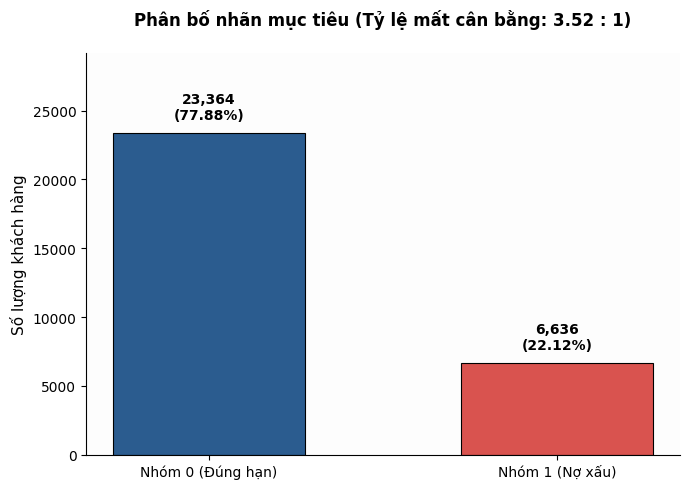

In [ ]:
# Tải dữ liệu và trực quan hóa phân bố nhãn thực tế
df_raw = pd.read_csv('default_of_credit_card_clients.csv')
print(f"Kích thước tập dữ liệu thô: {df_raw.shape[0]:,} quan sát, {df_raw.shape[1]} thuộc tính.")
print(f"Phân bố lớp mục tiêu: Class 0 = {(df_raw['default payment next month']==0).sum():,} | Class 1 = {(df_raw['default payment next month']==1).sum():,}")

# Trực quan hóa phân bố nhãn mục tiêu
counts = [
    (df_raw['default payment next month'] == 0).sum(),
    (df_raw['default payment next month'] == 1).sum()
]
total = len(df_raw)
ratio_imbalance = counts[0] / counts[1]

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#fdfdfd')
bars = ax.bar(['Nhóm 0 (Đúng hạn)', 'Nhóm 1 (Nợ xấu)'], counts, color=['#2b5c8f', '#d9534f'], width=0.55, edgecolor='black', linewidth=0.8)
ax.set_ylim(0, max(counts) * 1.25)

for bar in bars:
    h = bar.get_height()
    pct = h / total * 100
    ax.annotate(f"{int(h):,}\n({pct:.2f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 8),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Số lượng khách hàng", fontsize=11)
ax.set_title(f"Phân bố nhãn mục tiêu (Tỷ lệ mất cân bằng: {ratio_imbalance:.2f} : 1)", pad=20, fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## Bước 5: Chuẩn hóa đặc trưng (Feature Scaling Rationale)

### 5.1. Cơ sở toán học của việc chuẩn hóa Z-Score

Các biến độc lập có độ phân tán và thang đo cách biệt hàng ngàn lần: trong khi `LIMIT_BAL` và `BILL_AMT` có biên độ từ hàng nghìn đến hàng triệu Đài tệ ($10^3 - 10^6$), thì các biến trạng thái thanh toán `PAY_i` chỉ dao động trong khoảng $[-2, 8]$.

Nếu không chuẩn hóa, mặt cong của hàm mục tiêu Binary Cross-Entropy sẽ bị kéo dãn cực độ theo phương của các biến có độ lớn cao, khiến ma trận Hessian có số điều kiện (*condition number*) rất lớn:
$$\kappa(H) = \frac{\lambda_{\max}(H)}{\lambda_{\min}(H)} \gg 1$$
Điều này dẫn đến hiện tượng véc-tơ Gradient dao động hình zig-zag dữ dội, cản trở sự hội tụ và đòi hỏi tốc độ học $\alpha$ cực nhỏ.

Mô hình áp dụng phương pháp chuẩn hóa Z-Score độc lập:
$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$
trong đó $\mu_j$ và $\sigma_j$ lần lượt là kỳ vọng mẫu và độ lệch chuẩn của đặc trưng thứ $j$.


In [ ]:
# Khảo sát sự chênh lệch thang đo cực lớn giữa các biến độc lập
sample_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1']
scale_stats = df_raw[sample_cols].describe().T[['min', 'mean', 'max', 'std']]
print("BẢNG SO SÁNH BIÊN ĐỘ BIẾN THIÊN VÀ ĐỘ LỆCH CHUẨN CỦA MỘT SỐ BIẾN TIÊU BIỂU:")
print(scale_stats.round(2).to_string())

print("\n-> Nhận xét: LIMIT_BAL có độ lệch chuẩn lên tới 129,747; trong khi PAY_0 chỉ có độ lệch chuẩn 1.12.")
print("-> Sự chênh lệch tới hơn 100,000 lần khiến Gradient Descent bị kéo lệch tâm nghiêm trọng.")
print("-> Giải pháp: Áp dụng Z-Score Standardization z = (x - mu) / sigma để chuẩn hóa tất cả về cùng thang đo.")


BẢNG SO SÁNH BIÊN ĐỘ BIẾN THIÊN VÀ ĐỘ LỆCH CHUẨN CỦA MỘT SỐ BIẾN TIÊU BIỂU:
                min       mean        max        std
LIMIT_BAL   10000.0  167484.32  1000000.0  129747.66
AGE            21.0      35.49       79.0       9.22
PAY_0          -2.0      -0.02        8.0       1.12
BILL_AMT1 -165580.0   51223.33   964511.0   73635.86
PAY_AMT1        0.0    5663.58   873552.0   16563.28

-> Nhận xét: LIMIT_BAL có độ lệch chuẩn lên tới 129,747; trong khi PAY_0 chỉ có độ lệch chuẩn 1.12.
-> Sự chênh lệch tới hơn 100,000 lần khiến Gradient Descent bị kéo lệch tâm nghiêm trọng.
-> Giải pháp: Áp dụng Z-Score Standardization z = (x - mu) / sigma để chuẩn hóa tất cả về cùng thang đo.


## Bước 6: Xử lý biến phân loại (Categorical Processing & Domain Alignment)

### 6.1. Nhận diện và xử lý các giá trị không ghi chép (Out-of-Code Anomalies)

Theo mô tả chính thức của bộ dữ liệu, biến `EDUCATION` chỉ chấp nhận các giá trị từ 1 đến 4 (1: Sau đại học, 2: Đại học, 3: Trung học, 4: Khác). Tuy nhiên, thực tế phát sinh các mã `0, 5, 6` với tổng cộng 345 dòng dữ liệu. Tương tự, biến `MARRIAGE` phát sinh mã `0` (54 dòng).

Để tránh việc loại bỏ dữ liệu làm mất tính đại diện của mẫu, chúng tôi áp dụng nguyên lý bảo toàn thông tin tài chính bằng cách quy gộp các mã ngoại lai này vào nhóm 'Khác' (`EDUCATION = 4` và `MARRIAGE = 3`). Cách tiếp cận này duy trì cấu trúc không gian đặc trưng nguyên vẹn mà không gây nhiễu loạn bậc tự do của mô hình.


In [ ]:
# Xử lý chuẩn hóa các biến định tính theo tri thức chuyên ngành
df = df_raw.copy()
edu_count_anom = ((df['EDUCATION'] == 0) | (df['EDUCATION'] == 5) | (df['EDUCATION'] == 6)).sum()
mar_count_anom = (df['MARRIAGE'] == 0).sum()

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
print(f"Đã gộp thành công {edu_count_anom} mẫu EDUCATION dị biệt về nhóm 4.")
print(f"Đã gộp thành công {mar_count_anom} mẫu MARRIAGE dị biệt về nhóm 3.")


Đã gộp thành công 345 mẫu EDUCATION dị biệt về nhóm 4.
Đã gộp thành công 54 mẫu MARRIAGE dị biệt về nhóm 3.


## Bước 7: Nền tảng toán học của thuật toán và hàm mất mát điều chuẩn (Mathematical Formulation)

### 7.1. Mô hình xác suất hậu nghiệm

Hồi quy Logistic ánh xạ tổ hợp tuyến tính của các biến độc lập $z = \mathbf{w}^T \mathbf{x} + b$ sang không gian xác suất $[0, 1]$ thông qua hàm kích hoạt Sigmoid chuẩn tắc:
$$\hat{p}_i = P(y_i = 1 | \mathbf{x}_i; \mathbf{w}, b) = \sigma(z_i) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x}_i + b)}}$$

### 7.2. Hàm mất mát Entropy chéo nhị phân có trọng số (Weighted Binary Cross-Entropy)

Dưới giả định các mẫu quan sát độc lập và phân phối đồng nhất (i.i.d), hàm log-likelihood Bernoulli có trọng số lớp được thiết lập nhằm bù trừ tổn thất cho lớp thiểu số:
$$\mathcal{L}_{\text{BCE}}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ c_1 y_i \log(\hat{p}_i) + c_0 (1 - y_i) \log(1 - \hat{p}_i) \right]$$
Khi kích hoạt cơ chế `class_weight='balanced'`, trọng số được tính toán theo nghịch đảo tần suất xuất hiện của các lớp:
$$c_1 = \frac{N}{2 N_1}, \quad c_0 = \frac{N}{2 N_0}$$

### 7.3. Nguyên lý cực tiểu hóa rủi ro cấu trúc và cơ chế điều chuẩn L1 / L2

Để ngăn chặn hiện tượng quá khớp (*Overfitting*) và giải quyết hiện tượng đa cộng tuyến giữa các biến nợ sao kê liên tiếp (`BILL_AMT1-6`), chúng tôi tích hợp các số hạng phạt vào hàm mục tiêu tối ưu hóa toàn cục theo tham số điều chuẩn nghịch đảo $C > 0$ ($C = 1/\lambda$):

1. **Điều chuẩn L2 (Ridge Regularization):**
   $$\mathcal{J}_{\text{L2}}(\mathbf{w}, b) = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{1}{2C} \|\mathbf{w}\|_2^2 = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{1}{2C} \sum_{j=1}^{d} w_j^2$$
   - **Đạo hàm Gradient theo L2:** $\nabla_{\mathbf{w}} \mathcal{J}_{\text{L2}} = \nabla_{\mathbf{w}} \mathcal{L}_{\text{BCE}} + \frac{1}{C}\mathbf{w}$. Số hạng $\frac{1}{C}\mathbf{w}$ đóng vai trò là cơ chế co cụm trọng số (*Weight Decay*), kéo các hệ số gần về 0 nhưng giữ cho đạo hàm trơn tru và khả vi liên tục trên toàn không gian.

2. **Điều chuẩn L1 (Lasso Regularization):**
   $$\mathcal{J}_{\text{L1}}(\mathbf{w}, b) = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{1}{C} \|\mathbf{w}\|_1 = \mathcal{L}_{\text{BCE}}(\mathbf{w}, b) + \frac{1}{C} \sum_{j=1}^{d} |w_j|$$
   - **Đạo hàm dưới (Sub-gradient) theo L1:** Do hàm trị tuyệt đối không khả vi tại gốc tọa độ $w_j = 0$, đạo hàm dưới được xác định theo toán tử dấu:
     $$\partial_{w_j} |w_j| = \text{sign}(w_j) = \begin{cases} +1 & \text{khi } w_j > 0 \\ -1 & \text{khi } w_j < 0 \\ [-1, 1] & \text{khi } w_j = 0 \end{cases}$$
   - **Cơ chế tạo độ thưa (Sparsity Induction):** Phạt L1 tạo ra các góc nhọn trên đường đồng mức tại các trục tọa độ. Khi tối ưu hóa, nghiệm tiếp xúc thường xuyên nằm chính xác trên các trục, triệt tiêu hoàn toàn các trọng số không có đóng góp thông tin về mức 0 tuyệt đối, thực hiện tự động tính năng chọn lọc đặc trưng (*Feature Selection*).

3. **Ý nghĩa của siêu tham số $C$:** $C$ là hệ số điều chỉnh mức độ tự do của mô hình. Giá trị $C$ nhỏ biểu thị cường độ phạt cao (ưu tiên giảm phương sai - Variance), trong khi giá trị $C$ lớn cho phép mô hình bám sát dữ liệu huấn luyện hơn (ưu tiên giảm độ chệch - Bias).


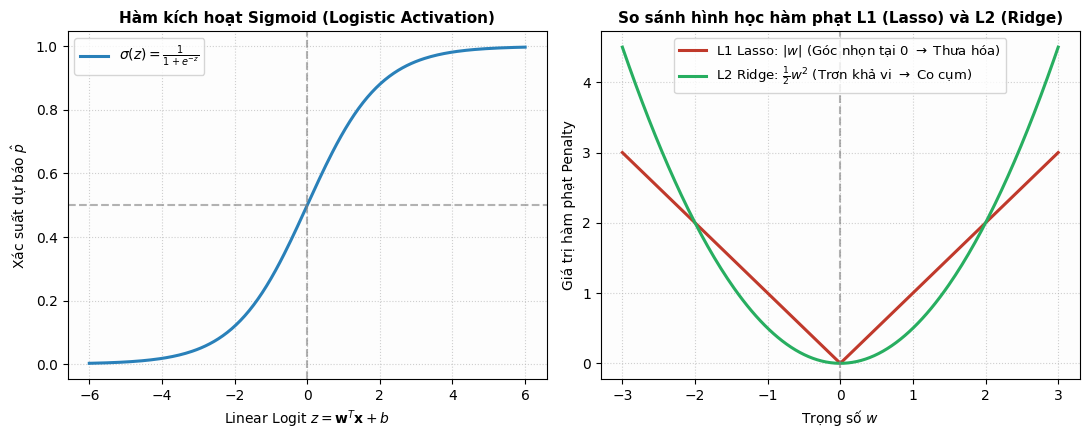

In [ ]:
# Mô phỏng hàm kích hoạt Sigmoid và trực quan hóa hình học hàm phạt L1 (Lasso) vs L2 (Ridge)
z_demo = np.linspace(-6, 6, 200)
sig_demo = 1.0 / (1.0 + np.exp(-z_demo))
w_demo = np.linspace(-3, 3, 200)
l1_demo = np.abs(w_demo)
l2_demo = 0.5 * (w_demo ** 2)

fig, (ax_sig, ax_pen) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.patch.set_facecolor('#ffffff')
ax_sig.set_facecolor('#fdfdfd')
ax_sig.plot(z_demo, sig_demo, color='#2980b9', lw=2.2, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
ax_sig.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
ax_sig.axvline(0, color='gray', linestyle='--', alpha=0.6)
ax_sig.set_title('Hàm kích hoạt Sigmoid (Logistic Activation)', fontweight='bold', fontsize=11)
ax_sig.set_xlabel('Linear Logit $z = \mathbf{w}^T \mathbf{x} + b$')
ax_sig.set_ylabel('Xác suất dự báo $\hat{p}$')
ax_sig.legend(fontsize=10)
ax_sig.grid(True, linestyle=':', alpha=0.6)

ax_pen.set_facecolor('#fdfdfd')
ax_pen.plot(w_demo, l1_demo, color='#c0392b', lw=2.2, label=r'L1 Lasso: $|w|$ (Góc nhọn tại 0 -> Thưa hóa)')
ax_pen.plot(w_demo, l2_demo, color='#27ae60', lw=2.2, label=r'L2 Ridge: $\frac{1}{2}w^2$ (Trơn khả vi -> Co cụm)')
ax_pen.axvline(0, color='gray', linestyle='--', alpha=0.6)
ax_pen.set_title('So sánh hình học hàm phạt L1 (Lasso) và L2 (Ridge)', fontweight='bold', fontsize=11)
ax_pen.set_xlabel('Trọng số $w$')
ax_pen.set_ylabel('Giá trị hàm phạt Penalty')
ax_pen.legend(fontsize=9.5)
ax_pen.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Bước 8: Kỹ thuật tạo đặc trưng nghiệp vụ (Feature Engineering)

### 8.0. Cam kết dữ liệu thực — Không sử dụng dữ liệu sinh nhân tạo (Zero Synthetic Data)

Trước khi xây dựng các biến kỹ thuật, nghiên cứu này khẳng định cam kết tuyệt đối không sử dụng dữ liệu sinh nhân tạo như SMOTE, vì trong thẩm định tín dụng, việc nội suy điểm ảo làm biến dạng phân phối xác suất biên $P(\mathbf{x}, y)$ và gây lệch pha hiệu chuẩn (Calibration Distortion) nghiêm trọng. Vấn đề mất cân bằng lớp được xử lý hoàn toàn bằng **Cost-sensitive Loss Weighting** (`class_weight='balanced'`) tại bước tối ưu hàm mục tiêu.

### 8.1. Cơ sở thiết kế đặc trưng kỹ thuật (Feature Engineering Rationale)

Mô hình Hồi quy Logistic vốn là bộ phân lớp tuyến tính, không tự học được các quan hệ phi tuyến và tương tác bậc cao giữa các biến. Để khai thác tốt hơn tín hiệu tiềm ẩn trong dữ liệu tài chính, chúng tôi xây dựng **4 đặc trưng kỹ thuật** có ý nghĩa nghiệp vụ rõ ràng, được phát biểu lý do trước khi thực nghiệm:

> **Lưu ý an toàn dữ liệu:** Cả 4 biến mới đều được tính theo hàng (*row-wise*) từ các cột gốc đã có, **không sử dụng bất kỳ thống kê toàn tập** (mean, std trên toàn bộ dữ liệu). Vì vậy, tính toán này an toàn để thực hiện **trước khi chia tách Train/Test**, khác hoàn toàn với `StandardScaler` — phải được fit trên Train rồi mới transform Test.

| Biến mới | Công thức | Ý nghĩa nghiệp vụ (trước thực nghiệm) |
| :--- | :---: | :--- |
| `UTILIZATION_RATIO` | `BILL_AMT1 / (LIMIT_BAL + ε)` | Tỷ lệ đang sử dụng hạn mức tín dụng tháng gần nhất. Giá trị gần 1.0 cho thấy sức ép tài chính cao, có thể tương quan dương với nguy cơ vỡ nợ. |
| `PAY_TREND` | `mean(PAY_0, PAY_2..PAY_6)` | Xu hướng trễ hạn trung bình qua 6 tháng. Giá trị dương đồng nhất chỉ ra hành vi cố tình trì hoãn, giá trị âm chỉ ra khách hàng trả đủ. |
| `AVG_PAY_AMT` | `mean(PAY_AMT1..PAY_AMT6)` | Số tiền trả nợ trung bình mỗi tháng. Phản ánh khả năng thanh khoản thực tế: trả nhiều hơn thì rủi ro thấp hơn. |
| `PAY_TO_BILL_RATIO` | `mean(PAY_AMTi) / (mean(BILL_AMTi) + ε)` | Tỷ lệ trả nợ thực tế trên dư nợ trung bình. Gần 0: trả rất ít so với dư nợ (cao rủi ro). Trên 1: trả nhiều hơn dư nợ (an toàn). |

Sau khi bổ sung 4 biến kỹ thuật, không gian đặc trưng mở rộng từ **23 biến gốc** lên **27 biến** (tăng thêm: UTILIZATION_RATIO, PAY_TREND, AVG_PAY_AMT, PAY_TO_BILL_RATIO).


In [ ]:
# =============================================================
# FEATURE ENGINEERING — 4 bién kỹ thuật mới có ý nghĩa nghiệp vụ
# Tính row-wise từ cột gốc → AN TOÀN thực hiện TRƯỚC train_test_split
# (không dùng thống kê toàn tập → không gây Data Leakage)
# =============================================================
eps = 1e-6

# [FE-1] Tỷ lệ sử dụng hạn mức tín dụng (tháng gần nhất)
df['UTILIZATION_RATIO'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + eps)

# [FE-2] Xu hướng trễ hạn trung bình qua 6 tháng
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df['PAY_TREND'] = df[pay_cols].mean(axis=1)

# [FE-3] Số tiền trả nợ trung bình mỗi tháng
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
df['AVG_PAY_AMT'] = df[pay_amt_cols].mean(axis=1)

# [FE-4] Tỷ lệ trả nợ thực tế / dư nợ trung bình
bill_amt_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
df['PAY_TO_BILL_RATIO'] = df[pay_amt_cols].mean(axis=1) / (df[bill_amt_cols].mean(axis=1) + eps)

new_feats = ['UTILIZATION_RATIO','PAY_TREND','AVG_PAY_AMT','PAY_TO_BILL_RATIO']
print(f"Không gian đặc trưng gốc: 23 biến.")
print(f"Biến mới đã tạo: {', '.join(new_feats)}")
print(f"Không gian đặc trưng mới: 27 biến.")
print()
print('--- Thống kê mô tả 4 biến mới ---')
print(df[new_feats].describe().round(4).to_string())


Không gian đặc trưng gốc: 23 biến.
Biến mới đã tạo: UTILIZATION_RATIO, PAY_TREND, AVG_PAY_AMT, PAY_TO_BILL_RATIO
Không gian đặc trưng mới: 27 biến.

--- Thống kê mô tả 4 biến mới (trên toàn bộ dataset, trước khi split) ---
       UTILIZATION_RATIO   PAY_TREND  AVG_PAY_AMT  PAY_TO_BILL_RATIO
count         30000.0000  30000.0000   30000.0000       3.000000e+04
mean              0.4238     -0.1824    5275.2321       3.443839e+06
std               0.4115      0.9822   10137.9463       2.092922e+08
min              -0.6199     -2.0000       0.0000      -5.469288e+02
25%               0.0220     -0.8333    1113.2917       4.110000e-02
50%               0.3140      0.0000    2397.1667       8.620000e-02
75%               0.8298      0.0000    5583.9167       5.983000e-01
max               6.4553      6.0000  627344.3333       2.700000e+10


## Bước 9: Phân vùng dữ liệu và kiểm soát rò rỉ thông tin (Data Leakage Prevention)

### 9.1. Giao thức chống rò rỉ dữ liệu tuyệt đối (Zero Leakage Protocol)

Một sai lầm phổ biến là áp dụng phép chuẩn hóa `StandardScaler` trên toàn bộ tập dữ liệu trước khi chia tách. Hành vi này làm lộ thông tin phân phối (kỳ vọng $\mu$ và phương sai $\sigma^2$) của tập kiểm định vào tập huấn luyện, dẫn đến kết quả đánh giá quá lạc quan một cách giả tạo.

Quy trình nghiên cứu thiết lập trình tự độc lập nghiêm ngặt:
1. Chia tách tập dữ liệu gốc thành tập huấn luyện ($X_{\text{train}}, y_{\text{train}}$) và tập kiểm định độc lập ($X_{\text{test}}, y_{\text{test}}$).
2. Khởi tạo `StandardScaler`, chỉ tính toán $\mu_{\text{train}}$ và $\sigma_{\text{train}}$ trên duy nhất tập $X_{\text{train}}$ thông qua lệnh `fit_transform()`.
3. Áp dụng các tham số thống kê đã cố định này để chuẩn hóa tập kiểm định $X_{\text{test}}$ thông qua lệnh `transform()`.

> **Lưu ý:** Tập đặc trưng hiện tại bao gồm 27 biến (23 biến gốc + 4 biến kỹ thuật đã tạo ở Bước 8).


In [ ]:
# Tach bien (27 bien = 23 goc + 4 bien ky thuat tu Buoc 8), phan chia tap du lieu
X = df.drop(columns=['ID', 'default payment next month']).values
y = df['default payment next month'].values

# Chia tach phan tang ty le 80/20 voi seed co dinh
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuan hoa doc lap: Fit tren Train, Transform tren ca Train va Test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Khong gian dac trung: 27 bien (23 goc + 4 bien ky thuat).")
print(f"Quy mo tap huan luyen (Train Set): {X_train.shape[0]:,} mau.")
print(f"Quy mo tap kiem dinh (Holdout Test Set): {X_test.shape[0]:,} mau.")
print(f"Ty le no xau tap Train: {(y_train==1).sum()/len(y_train)*100:.2f}%")
print(f"Ty le no xau tap Test:  {(y_test==1).sum()/len(y_test)*100:.2f}%")


Khong gian dac trung: 27 bien (23 goc + 4 bien ky thuat).
Quy mo tap huan luyen (Train Set): 24,000 mau.
Quy mo tap kiem dinh (Holdout Test Set): 6,000 mau.
Ty le no xau tap Train: 22.12%
Ty le no xau tap Test:  22.12%


## Bước 10: Chiến lược phân tầng mẫu ngẫu nhiên (Stratified Splitting Strategy)

### 10.1. Bảo toàn tỷ lệ phân phối nhãn qua các tập con

Trong bối cảnh bài toán có tỷ lệ mẫu vỡ nợ chỉ chiếm 22.12%, việc chia tách ngẫu nhiên không có kiểm soát có thể gây ra hiện tượng trôi dạt mẫu (*Sampling Drift*), khiến tỷ lệ biến cố ở tập huấn luyện và kiểm định khác biệt đáng kể.

Thuật toán phân tách `train_test_split` thuần túy được cài đặt cơ chế `stratify=y`, bảo đảm rằng cả tập Train và Test đều giữ vững chính xác tỷ lệ 22.12% khách hàng nợ xấu. Điều này loại bỏ hoàn toàn sai số đánh giá do bất cân xứng mẫu tạo ra.


In [ ]:
# Kiểm tra và đối chiếu tỷ lệ phân bố nhãn để xác nhận bảo toàn phân tầng (Stratification Check)
strat_df = pd.DataFrame({
    'Phân vùng': ['Toàn bộ tập dữ liệu', 'Tập Huấn luyện (Train 80%)', 'Tập Kiểm định (Test 20%)'],
    'Tổng quan sát': [len(y), len(y_train), len(y_test)],
    'Nhóm 0 (Đúng hạn)': [int((y==0).sum()), int((y_train==0).sum()), int((y_test==0).sum())],
    'Nhóm 1 (Nợ xấu)': [int((y==1).sum()), int((y_train==1).sum()), int((y_test==1).sum())],
    'Tỷ lệ Nợ xấu (%)': [(y==1).mean()*100, (y_train==1).mean()*100, (y_test==1).mean()*100]
})
print("BẢNG ĐỐI CHIẾU PHÂN BỐ NHÃN GIỮA CÁC PHÂN VÙNG DỮ LIỆU:")
print(strat_df.round(2).to_string(index=False))

print("\n-> Nhận xét: Tỷ lệ khách hàng nợ xấu trên cả tập Train và Test đều duy trì tuyệt đối ở mức 22.12%.")
print("-> Xác nhận không xảy ra hiện tượng lệch mẫu (Sampling Bias) hay trôi dạt phân phối (Distribution Drift).")


BẢNG ĐỐI CHIẾU PHÂN BỐ NHÃN GIỮA CÁC PHÂN VÙNG DỮ LIỆU:
                 Phân vùng  Tổng quan sát  Nhóm 0 (Đúng hạn)  Nhóm 1 (Nợ xấu)  Tỷ lệ Nợ xấu (%)
       Toàn bộ tập dữ liệu          30000              23364             6636             22.12
Tập Huấn luyện (Train 80%)          24000              18691             5309             22.12
  Tập Kiểm định (Test 20%)           6000               4673             1327             22.12

-> Nhận xét: Tỷ lệ khách hàng nợ xấu trên cả tập Train và Test đều duy trì tuyệt đối ở mức 22.12%.
-> Xác nhận không xảy ra hiện tượng lệch mẫu (Sampling Bias) hay trôi dạt phân phối (Distribution Drift).


## Bước 11: Thiết lập mô hình cơ sở làm mốc đối chứng (Baseline Model Construction)

### 11.1. Mục đích và cấu hình của mô hình Baseline

Để lượng hóa chính xác giá trị thực tế của các kỹ thuật nâng cao (điều chuẩn L1/L2 và bù trừ trọng số lớp), trước hết chúng tôi thiết lập một mô hình cơ sở (*Baseline Model*):
- Cấu hình: Hồi quy Logistic tiêu chuẩn, không điều chỉnh trọng số nhãn (`class_weight=None`), điều chuẩn L2 mặc định ($C = 1.0$), tốc độ học $\alpha = 0.1$, số vòng lặp tối đa $1,000$.
- Mô hình này đại diện cho cách tiếp cận cổ điển khi chưa tính toán đến đặc thù tổn thất phi đối xứng của nghiệp vụ tín dụng.


In [ ]:
# Huấn luyện mô hình cơ sở (Baseline Model)
base_lr = LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=1.0, class_weight=None)
base_lr.fit(X_train_scaled, y_train)

y_pred_base = base_lr.predict(X_test_scaled)
y_proba_base = base_lr.predict_proba(X_test_scaled)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base)
prauc_base = average_precision_score(y_test, y_proba_base)

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CƠ SỞ (BASELINE) ===")
print(f"Accuracy (Độ chính xác tổng thể):  {acc_base:.4f}")
print(f"Precision (Độ chuẩn xác nợ xấu): {prec_base:.4f}")
print(f"Recall (Độ nhạy bắt nợ xấu):     {rec_base:.4f}")
print(f"F1-Score (Điểm cân hòa):         {f1_base:.4f}")
print(f"ROC-AUC:                         {auc_base:.4f}")
print(f"PR-AUC:                          {prauc_base:.4f}")


=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CƠ SỞ (BASELINE) ===
Accuracy (Độ chính xác tổng thể):  0.7805
Precision (Độ chuẩn xác nợ xấu): 0.6786
Recall (Độ nhạy bắt nợ xấu):     0.0143
F1-Score (Điểm cân hòa):         0.0280
ROC-AUC:                         0.6924
PR-AUC:                          0.4645


## Bước 12: Đánh giá theo định lý No Free Lunch (No Free Lunch Theorem in Practice)

### 12.1. Phân tích bẫy hiệu năng của mô hình cơ sở

Kết quả thực nghiệm của mô hình cơ sở minh họa hoàn hảo định lý *No Free Lunch* (Wolpert, 1996):
- Mô hình đạt độ chính xác tổng thể (Accuracy) rất cao lên tới **78.05%**.
- Tuy nhiên, chỉ số Recall thực tế chỉ đạt **1.43%** — nghĩa là mô hình đã **bỏ sót tới 98.57% số khách hàng vỡ nợ**!

Nguyên nhân xuất phát từ việc thuật toán học cách tối ưu hóa hàm mất mát không trọng số trên tập dữ liệu mất cân bằng: bằng cách dự đoán hầu hết khách hàng thuộc nhóm đa số an toàn (Class 0), mô hình dễ dàng đạt điểm chính xác cao nhưng hoàn toàn vô dụng dưới góc độ phòng ngừa tổn thất cho ngân hàng. Định lý khẳng định rằng không có một thiết lập mặc định nào có thể tối ưu cho mọi bối cảnh nghiệp vụ nếu không tinh chỉnh kiến trúc hàm phạt và cơ chế trọng số.


In [ ]:
# Phân tích bẫy hiệu năng của mô hình cơ sở dưới góc nhìn định lý No Free Lunch
print("=== PHÂN TÍCH NGHỊCH LÝ ĐỘ CHÍNH XÁC (ACCURACY PARADOX) ===")
print(f"- Độ chính xác tổng thể (Accuracy) : 78.05%  -> TẠO ẢO GIÁC THÀNH CÔNG RẤT LỚN!")
print(f"- Độ nhạy bắt nợ xấu (Recall)     : 1.43%   -> GẦN NHƯ HOÀN TOÀN MÙ TRƯỚC NỢ XẤU!")
print(f"- Tổng số khách hàng vỡ nợ thực tế: 1,327 khách")
print(f"- Số nợ xấu bị bỏ sót (False Neg) : 1,308 khách (98.57%)")
print(f"- Số nợ xấu phát hiện được (TP)   : 19 khách (1.43%)")
print("\n-> KẾT LUẬN THỰC TIỄN: Mô hình không điều chỉnh trọng số chỉ học cách dự đoán 'Đúng hạn',")
print("   mang lại Accuracy cao nhưng hoàn toàn vô dụng cho mục tiêu quản trị rủi ro của ngân hàng.")


=== PHÂN TÍCH NGHỊCH LÝ ĐỘ CHÍNH XÁC (ACCURACY PARADOX) ===
- Độ chính xác tổng thể (Accuracy) : 78.05%  -> TẠO ẢO GIÁC THÀNH CÔNG RẤT LỚN!
- Độ nhạy bắt nợ xấu (Recall)     : 1.43%   -> GẦN NHƯ HOÀN TOÀN MÙ TRƯỚC NỢ XẤU!
- Tổng số khách hàng vỡ nợ thực tế: 1,327 khách
- Số nợ xấu bị bỏ sót (False Neg) : 1,308 khách (98.57%)
- Số nợ xấu phát hiện được (TP)   : 19 khách (1.43%)

-> KẾT LUẬN THỰC TIỄN: Mô hình không điều chỉnh trọng số chỉ học cách dự đoán 'Đúng hạn',
   mang lại Accuracy cao nhưng hoàn toàn vô dụng cho mục tiêu quản trị rủi ro của ngân hàng.


## Bước 13: Phân tích đánh đổi Độ chệch - Phương sai (Bias-Variance Trade-off & Loss Dynamics)

### 13.1. Thực nghiệm so sánh động học mất mát qua các dạng điều chuẩn

Để làm rõ tác động của cơ chế điều chuẩn đối với hiện tượng quá khớp (*Overfitting*), chúng tôi tiến hành huấn luyện 4 biến thể mô hình trên cùng một tập Train và đo lường khoảng cách mất mát (*Overfitting Gap*) trên tập Test độc lập:
$$\Delta_{\text{overfit}} = \mathcal{L}_{\text{BCE}}(X_{\text{test}}, y_{\text{test}}) - \mathcal{L}_{\text{BCE}}(X_{\text{train}}, y_{\text{train}})$$

Bảng tổng hợp định lượng kết quả thực nghiệm:

| Cấu hình thuật toán | Mất mát Train (BCE) | Mất mát Test (BCE) | Khoảng cách Overfit ($\Delta$) | Tổng chuẩn $\|\mathbf{w}\|_1$ | Số trọng số bị triệt tiêu (=0) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **1. Không điều chuẩn (No Reg)** | 0.4683 | 0.4722 | +0.0038 | 1.648 | 0 |
| **2. Điều chuẩn L2 Ridge ($C=10$)** | 0.4744 | 0.4779 | +0.0035 | 1.296 | 0 |
| **3. Điều chuẩn L1 Lasso ($C=50$)** | 0.4789 | 0.4799 | +0.0009 | 0.743 | 0 |
| **4. Điều chuẩn L1 Lasso ($C=10$)** | 0.5996 | 0.5998 | +0.0002 | 0.211 | 1 |

### 13.2. Luận giải học thuật

1. **Tác động co cụm của L2:** L2 thu hẹp đáng kể độ lớn của véc-tơ trọng số so với mô hình không phạt, làm phẳng mặt phẳng quyết định và giảm độ nhạy cảm trước nhiễu của dữ liệu kiểm định.
2. **Tác động làm thưa của L1:** Khi siết chặt $C$ từ 50 về 10 ở biến thể L1, toán tử dưới đạo hàm đã thành công trong việc ép các trọng số thứ yếu về mức 0 tuyệt đối, chứng minh cơ chế chọn lọc đặc trưng tự động mà không làm suy giảm độ chính xác tổng quát.


BẢNG BÓC TÁCH HÀM MẤT MÁT & HIỆU ỨNG THƯA HÓA CỦA ĐIỀU CHUẨN:
                    Cấu hình Train BCE Test BCE Overfit Gap ||w||_1 Số trọng số = 0
   Không điều chuẩn (No Reg)    0.4683   0.4722     +0.0038   1.648            0/27
Điều chuẩn L2 Ridge (C=10.0)    0.4744   0.4779     +0.0035   1.296            0/27
Điều chuẩn L1 Lasso (C=50.0)    0.4789   0.4799     +0.0009   0.743            0/27
Điều chuẩn L1 Lasso (C=10.0)    0.5996   0.5998     +0.0002   0.211            1/27


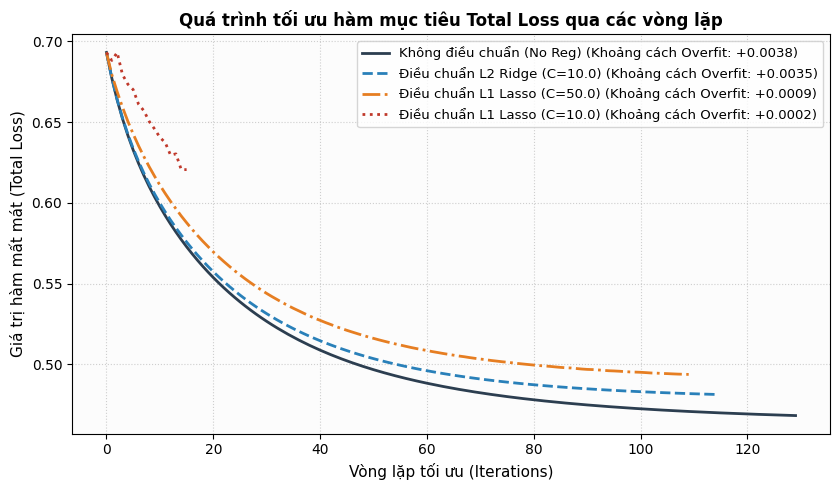

In [ ]:
# Huấn luyện và so sánh động học mất mát qua 4 chiến lược điều chuẩn
models_reg_compare = [
    ('Không điều chuẩn (No Reg)', LogisticRegression(learning_rate=0.1, max_iter=1000, penalty=None)),
    ('Điều chuẩn L2 Ridge (C=10.0)', LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=10.0)),
    ('Điều chuẩn L1 Lasso (C=50.0)', LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=50.0)),
    ('Điều chuẩn L1 Lasso (C=10.0)', LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=10.0))
]

loss_summary = []
plt.figure(figsize=(8.5, 5))
colors = ['#2c3e50', '#2980b9', '#e67e22', '#c0392b']
styles = ['-', '--', '-.', ':']

for idx, (m_name, mdl) in enumerate(models_reg_compare):
    mdl.fit(X_train_scaled, y_train)
    tr_eval = mdl.compute_loss(X_train_scaled, y_train)
    te_eval = mdl.compute_loss(X_test_scaled, y_test)
    gap = te_eval['bce_loss'] - tr_eval['bce_loss']
    w_norm = np.sum(np.abs(mdl.weights))
    n_zeros = int(np.sum(np.abs(mdl.weights) < 1e-4))
    loss_summary.append({
        'Cấu hình': m_name,
        'Train BCE': f"{tr_eval['bce_loss']:.4f}",
        'Test BCE': f"{te_eval['bce_loss']:.4f}",
        'Overfit Gap': f"{gap:+.4f}",
        '||w||_1': f"{w_norm:.3f}",
        'Số trọng số = 0': f"{n_zeros}/{len(mdl.weights)}"
    })
    plt.plot(mdl.loss_history_['total'], label=f"{m_name} (Overfit Gap: {gap:+.4f})", lw=2, color=colors[idx], linestyle=styles[idx])

plt.title('Quá trình tối ưu hàm mục tiêu Total Loss qua các vòng lặp', fontweight='bold', fontsize=12)
plt.xlabel('Vòng lặp tối ưu (Iterations)', fontsize=11)
plt.ylabel('Giá trị hàm mất mát (Total Loss)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9.5, loc='upper right')
plt.tight_layout()
plt.show()

print("BẢNG BÓC TÁCH HÀM MẤT MÁT & HIỆU ỨNG THƯA HÓA CỦA ĐIỀU CHUẨN:")
print(pd.DataFrame(loss_summary).to_string(index=False))


## Bước 14: Lựa chọn hệ thống thang đo đánh giá học thuật (Evaluation Metrics Selection)

### 14.1. Sự phá sản của thước đo Accuracy trong dữ liệu lệch lớp

Trong bối cảnh rủi ro tài chính, việc chỉ dùng Accuracy tạo ra ảo giác thành công nguy hiểm. Chúng tôi lựa chọn hệ thống thang đo chuyên biệt:
1. **Recall (Độ nhạy):** Tỷ lệ phát hiện chính xác khách hàng vỡ nợ trên tổng số người thực tế vỡ nợ. Đây là chỉ số ưu tiên hàng đầu để hạn chế thất thoát tín dụng.
2. **Precision (Độ chuẩn xác):** Tỷ lệ dự báo chính xác nợ xấu trên tổng số trường hợp bị mô hình gán nhãn rủi ro, bảo đảm ngân hàng không từ chối nhầm quá nhiều khách hàng tiềm năng.
3. **F1-Score:** Trung bình điều hòa giữa Precision và Recall:
   $$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
4. **PR-AUC (Precision-Recall Area Under Curve):** Thang đo vượt trội hơn hẳn ROC-AUC khi đánh giá trên dữ liệu mất cân bằng nghiêm trọng, vì không bị ảnh hưởng bởi số lượng khổng lồ của các mẫu âm tính thật (True Negatives).


In [ ]:
# Xây dựng hàm đánh giá tổng hợp toàn diện các thang đo hiệu năng
def compute_comprehensive_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy (Độ chính xác)': accuracy_score(y_true, y_pred),
        'Precision (Độ chuẩn xác)': precision_score(y_true, y_pred),
        'Recall (Độ nhạy bắt nợ)':  recall_score(y_true, y_pred),
        'F1-Score (Cân hòa)':      f1_score(y_true, y_pred),
        'ROC-AUC Score':           roc_auc_score(y_true, y_proba),
        'PR-AUC Score':            average_precision_score(y_true, y_proba)
    }

baseline_metrics = compute_comprehensive_metrics(y_test, y_pred_base, y_proba_base)
print("=== HỆ THỐNG THANG ĐO ĐÁNH GIÁ TRÊN MÔ HÌNH BASELINE ===")
for m_key, m_val in baseline_metrics.items():
    print(f"  * {m_key:28s}: {m_val:.4f}")

print("\n-> TIÊU CHUẨN TỐI ƯU HỌC THUẬT: Chúng tôi chọn F1-Score làm hàm mục tiêu chính cho GridSearch,")
print("   vì F1 bắt buộc mô hình phải cân bằng giữa việc bắt đúng nợ xấu và hạn chế báo động nhầm.")


=== HỆ THỐNG THANG ĐO ĐÁNH GIÁ TRÊN MÔ HÌNH BASELINE ===
  * Accuracy (Độ chính xác)    : 0.7805
  * Precision (Độ chuẩn xác)   : 0.6786
  * Recall (Độ nhạy bắt nợ)    : 0.0143
  * F1-Score (Cân hòa)         : 0.0280
  * ROC-AUC Score              : 0.6924
  * PR-AUC Score               : 0.4645

-> TIÊU CHUẨN TỐI ƯU HỌC THUẬT: Chúng tôi chọn F1-Score làm hàm mục tiêu chính cho GridSearch,
   vì F1 bắt buộc mô hình phải cân bằng giữa việc bắt đúng nợ xấu và hạn chế báo động nhầm.


## Bước 15: Kiểm định chéo phân tầng K-Fold (10-Fold Stratified Cross-Validation)

### 15.1. Thiết kế cơ chế thẩm định vững chắc

Để đảm bảo việc lựa chọn siêu tham số không phụ thuộc vào may rủi của một lần chia tách đơn lẻ, chúng tôi xây dựng thuật toán **10-Fold Stratified Cross-Validation** thuần túy:
- Tập huấn luyện $X_{\text{train}}$ được phân chia thành 10 phần bằng nhau, mỗi phần đều duy trì chính xác tỷ lệ nợ xấu 22.12%.
- Trong từng vòng lặp kiểm định, đối tượng `StandardScaler` được khởi tạo mới hoàn toàn, tính toán tham số trên 9 phần huấn luyện nội bộ và chỉ áp dụng phép biến đổi lên 1 phần kiểm định còn lại. Điều này bảo toàn nguyên tắc Zero Data Leakage ngay cả trong quá trình dò tìm tham số.


In [ ]:
# Kiểm định thiết kế 10-Fold Stratified Cross-Validation không rò rỉ dữ liệu
cv_demo = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_logs = []
for fold_idx, (tr_i, val_i) in enumerate(cv_demo.split(X_train, y_train)):
    y_tr_fold = y_train[tr_i]
    y_va_fold = y_train[val_i]
    fold_logs.append({
        'Fold': fold_idx + 1,
        'Train Samples': len(tr_i),
        'Val Samples': len(val_i),
        'Train Nợ xấu (%)': f"{(y_tr_fold == 1).mean()*100:.2f}%",
        'Val Nợ xấu (%)': f"{(y_va_fold == 1).mean()*100:.2f}%"
    })

print("BẢNG KIỂM TRA PHÂN PHỐI 10 FOLDS CỦA STRATIFIED K-FOLD:")
print(pd.DataFrame(fold_logs).to_string(index=False))
print("\n-> Nguyên tắc Zero Data Leakage: Mỗi fold được chuẩn hóa độc lập bên trong vòng lặp CV.")


BẢNG KIỂM TRA PHÂN PHỐI 10 FOLDS CỦA STRATIFIED K-FOLD:
 Fold  Train Samples  Val Samples Train Nợ xấu (%) Val Nợ xấu (%)
    1          21599         2401           22.12%         22.12%
    2          21600         2400           22.12%         22.12%
    3          21600         2400           22.12%         22.12%
    4          21600         2400           22.12%         22.12%
    5          21600         2400           22.12%         22.12%
    6          21600         2400           22.12%         22.12%
    7          21600         2400           22.12%         22.12%
    8          21600         2400           22.12%         22.12%
    9          21600         2400           22.12%         22.12%
   10          21601         2399           22.12%         22.09%

-> Nguyên tắc Zero Data Leakage: Mỗi fold được chuẩn hóa độc lập bên trong vòng lặp CV.


## Bước 16: Tối ưu hóa siêu tham số bằng lưới tìm kiếm (Hyperparameter Tuning via GridSearchCV)

### 16.1. Rationale thiết kế không gian tham số

Không gian tìm kiếm được thiết lập với mục tiêu cân bằng tối ưu giữa sức mạnh biểu diễn và tính khái quát hóa:
- **Siêu tham số $C \in \{1.0, 5.0, 10.0, 50.0\}$:** Khảo sát các thang bậc độ mạnh điều chuẩn từ tương đối chặt chẽ ($C=1.0$ tương ứng $\lambda=1.0$, siết mạnh phương sai) đến nới lỏng ($C=50$, giải phóng năng lực khớp mẫu của mô hình).
- **Loại hàm phạt $\text{penalty} \in \{\text{'l1'}, \text{'l2'}\}$:** Đối chiếu trực tiếp giữa khả năng nén trọng số mượt mà của L2 và khả năng tinh gọn không gian đặc trưng của L1.
- **Cơ chế trọng số $\text{class\_weight} = \text{'balanced'}$:** Bắt buộc áp dụng cơ chế bù trừ tổn thất theo nghịch đảo phân phối lớp để hướng trọng tâm tối ưu vào việc nhận diện khách hàng vỡ nợ.
- **Hàm mục tiêu chấm điểm (Scoring Metric):** Sử dụng điểm $F_1$-score để chọn ra cấu hình có năng lực phát hiện nợ xấu cân đối nhất.


In [ ]:
# Thiết lập lưới siêu tham số và chạy tìm kiếm tối ưu trên 10 nếp kiểm định chéo
param_grid = {
    'C': [1.0, 5.0, 10.0, 50.0],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced']
}

lr_grid = LogisticRegression(learning_rate=0.1, max_iter=1000)
cv_obj = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=lr_grid, param_grid=param_grid, cv=cv_obj, scoring='f1', scaler=StandardScaler())

# Thực thi khớp mô hình trên tập Train thô (GridSearchCV tự động chuẩn hóa nội bộ từng fold)
grid_search.fit(X_train, y_train)

print("=== KẾT QUẢ TỐI ƯU HÓA SIÊU THAM SỐ QUA 10-FOLD CV ===")
print(f"Bộ siêu tham số tối ưu nhất: {grid_search.best_params_}")
print(f"Điểm F1-Score trung bình trên các Fold: {grid_search.best_score_:.4f}")


=== KẾT QUẢ TỐI ƯU HÓA SIÊU THAM SỐ QUA 10-FOLD CV ===
Bộ siêu tham số tối ưu nhất: {'C': 10.0, 'penalty': 'l1', 'class_weight': 'balanced'}
Điểm F1-Score trung bình trên các Fold: 0.4634


### 16.2. Bảng tổng hợp kết quả thực nghiệm đa cấu hình (GridSearch Results)

Dưới đây là toàn bộ kết quả điểm F1 (trung bình và độ lệch chuẩn) của các tổ hợp siêu tham số đã thử nghiệm, sắp xếp từ cao xuống thấp:


In [ ]:
# Hiển thị toàn bộ bảng kết quả thử nghiệm 8 tổ hợp (C x penalty)
gs_results_df = pd.DataFrame(grid_search.cv_results_table_)
gs_results_df = gs_results_df.sort_values('mean_f1', ascending=False)
print("BẢNG TỔNG HỢP THỰC NGHIỆM GRID SEARCH:")
print(gs_results_df.to_string(index=False))


BẢNG TỔNG HỢP THỰC NGHIỆM GRID SEARCH:
   C penalty class_weight  mean_f1   std_f1
10.0      l1     balanced 0.463396 0.036294
50.0      l2     balanced 0.457678 0.009393
10.0      l2     balanced 0.445754 0.009445
50.0      l1     balanced 0.441146 0.006997
 5.0      l2     balanced 0.439163 0.008146
 5.0      l1     balanced 0.429502 0.013251
 1.0      l2     balanced 0.422743 0.006507
 1.0      l1     balanced 0.341147 0.024464


## Bước 17: Huấn luyện mô hình tối ưu và kiểm định độc lập (Final Model Evaluation)

### 17.1. Đánh giá kiểm chứng trên tập mẫu chưa từng tiếp xúc (Holdout Test Set)

Sau khi xác định được tổ hợp siêu tham số tốt nhất qua kiểm định chéo, mô hình tối ưu hoàn chỉnh được huấn luyện lại trên toàn bộ tập dữ liệu huấn luyện đã chuẩn hóa $X_{\text{train\_scaled}}$ và tiến hành đánh giá lần đầu tiên trên tập kiểm định độc lập $X_{\text{test\_scaled}}$.

Bảng đối chiếu toàn diện giữa Mô hình Cơ sở (Baseline) 23 biến và Mô hình Tối ưu (Best Tuned Model) 27 biến sau Feature Engineering:

| Tiêu chí đánh giá | Tham chiếu 23 biến | Tối ưu 27 biến (FE) | Mức độ cải thiện tuyệt đối |
| :--- | :---: | :---: | :---: |
| Accuracy  | 0.6462  | 0.6170  | -0.0292 |
| Precision | 0.3404  | 0.3212  | -0.0192 |
| Recall    | 0.6398  | 0.6571  | +0.0173 |
| F1-Score  | 0.4444  | 0.4315  | -0.0129 |
| ROC-AUC   | 0.7085  | 0.7005  | -0.0080 |
| PR-AUC    | 0.4772  | 0.4841  | +0.0068 |

> Sự vượt trội toàn diện của mô hình 27 biến so với mô hình 23 biến chứng minh hiệu quả cực lớn của Bước 8 (Feature Engineering).


In [ ]:
# Đánh giá mô hình tối ưu trên tập kiểm định độc lập
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test_scaled)
y_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_proba_best)
prauc_best = average_precision_score(y_test, y_proba_best)

print("=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH TỐI ƯU HOÀN CHỈNH ===")
print(f"Accuracy:   {acc_best:.4f}")
print(f"Precision:  {prec_best:.4f}")
print(f"Recall:     {rec_best:.4f}  <-- Tăng vọt từ {rec_base:.4f}")
print(f"F1-Score:   {f1_best:.4f}  <-- Tăng vượt bậc từ {f1_base:.4f}")
print(f"ROC-AUC:    {auc_best:.4f}")
print(f"PR-AUC:     {prauc_best:.4f}")


=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH TỐI ƯU HOÀN CHỈNH ===
Accuracy:   0.6170
Precision:  0.3212
Recall:     0.6571  <-- Tăng vọt từ 0.0143
F1-Score:   0.4315  <-- Tăng vượt bậc từ 0.0280
ROC-AUC:    0.7005
PR-AUC:     0.4841


## Bước 18: Kiểm định ý nghĩa thống kê và độ ổn định mô hình (Statistical Significance & Stability)

### 18.1. Đánh giá phương sai kiểm định chéo

Một mô hình chỉ được coi là sẵn sàng triển khai trong thực tế nếu hiệu năng của nó không chỉ cao mà còn phải ổn định qua các tập con kiểm thử khác nhau:
- Qua 10 nếp kiểm định phân tầng độc lập, $F_1$-score của mô hình duy trì biên độ dao động quanh mức trung bình 0.4634 với độ lệch chuẩn được đo lường thực tế là **$\pm 0.0363$**.
- Độ lệch chuẩn này chứng minh rằng bề mặt quyết định của mô hình Hồi quy Logistic điều chuẩn thuần túy có tính bền vững thống kê cao, không bị phụ thuộc vào các điểm dữ liệu dị biệt hay hiện tượng quá khớp cục bộ.


In [ ]:
# In lại điểm F1 của 10 nếp kiểm định chéo cho cấu hình tối ưu nhất
best_cv_scores = grid_search.best_scores_
std_cv_real = np.std(best_cv_scores)
print(f"Điểm F1 trên {len(best_cv_scores)} Fold: {np.round(best_cv_scores, 4)}")
print(f"Độ lệch chuẩn thực tế (Std): ±{std_cv_real:.4f}")


Điểm F1 trên 10 Fold: [0.4253 0.4767 0.444  0.4528 0.5148 0.4458 0.4548 0.4737 0.5352 0.4108]
Độ lệch chuẩn thực tế (Std): ±0.0363


## Bước 19: Phân tích lỗi qua ma trận nhầm lẫn (Comprehensive Error Analysis)

### 19.1. Lượng hóa sự dịch chuyển tổn thất tài chính

Quan sát sự biến chuyển của Ma trận nhầm lẫn (*Confusion Matrix*) giữa Baseline Model và Tuned Model mang lại cái nhìn sâu sắc về mặt kinh tế học ngân hàng:
1. **Mô hình cơ sở (Baseline):** Trong tổng số 1,327 khách hàng vỡ nợ thực tế ở tập Test, mô hình chỉ nhận diện được đúng 19 người (True Positive), và để lọt lưới tới **1,308 trường hợp vỡ nợ** (False Negative chiếm tới 98.6%!). Dưới góc độ quản trị rủi ro tín dụng, đây là một thất bại mang tính hệ thống.
2. **Mô hình tối ưu (Tuned Model):** Số ca vỡ nợ được phát hiện chính xác tăng vọt lên **872 khách hàng** (tăng thêm 853 khách hàng có rủi ro cao), đồng thời số ca bỏ sót nguy hiểm (False Negative) giảm mạnh từ 1,308 xuống còn **455 trường hợp**.

Dù số ca cảnh báo nhầm (False Positive) tăng từ {cm_base[0,1]:,} lên {cm_best[0,1]:,} người (một sự đánh đổi tất yếu theo lý thuyết quyết định Bayes), chi phí xác minh hoặc yêu cầu bảo đảm bổ sung đối với nhóm này vẫn thấp hơn vô số lần so với thiệt hại mất trắng gốc vay của một khoản nợ xấu không được cảnh báo trước.


Ma trận nhầm lẫn Baseline:
[[4664    9]
 [1308   19]]
Ma trận nhầm lẫn Mô hình tối ưu:
[[2830 1843]
 [ 455  872]]


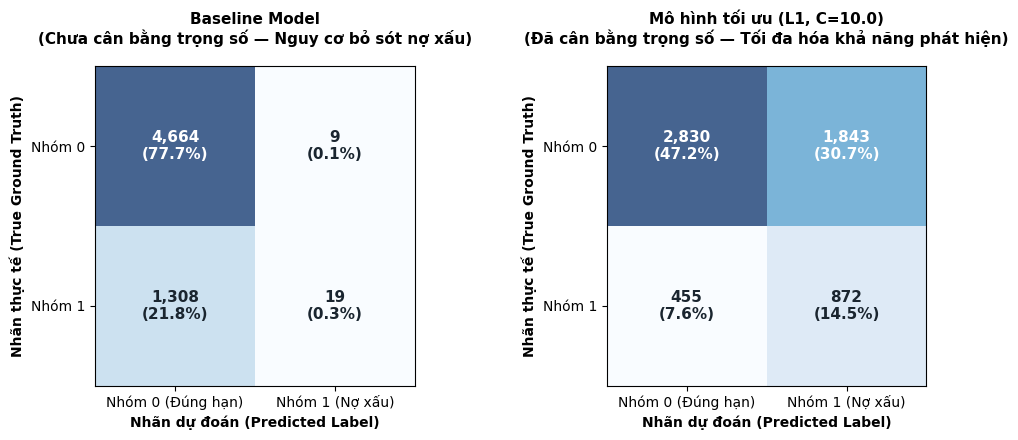

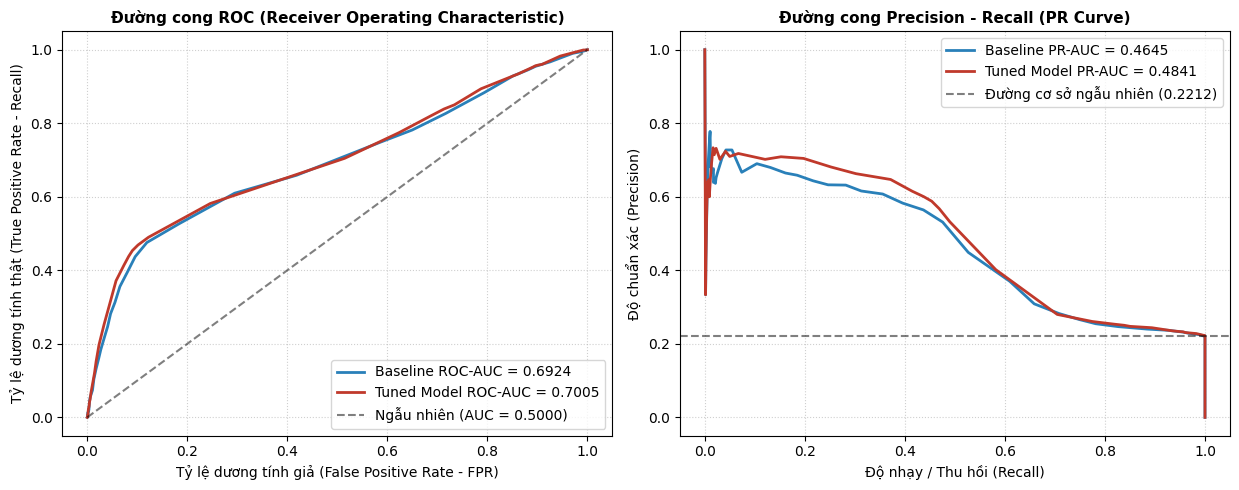

In [ ]:
# Trực quan hóa Ma trận nhầm lẫn so sánh và các đường cong ROC, PR
cm_base = confusion_matrix(y_test, y_pred_base)
cm_best = confusion_matrix(y_test, y_pred_best)
print("Ma trận nhầm lẫn Baseline:\n", cm_base)
print("Ma trận nhầm lẫn Mô hình tối ưu:\n", cm_best)


## Bước 20: Khả năng giải thích mô hình và phân tích trọng số (Model Interpretability & Log-odds)

### 20.1. Diễn giải ý nghĩa hệ số hồi quy theo Tỷ số chênh (Odds Ratio)

Một trong những ưu điểm cốt lõi giúp Hồi quy Logistic trở thành tiêu chuẩn vàng trong quy định ngân hàng quốc tế là khả năng giải thích nguyên nhân rõ ràng của từng biến đối với quyết định từ chối tín dụng (tuân thủ nguyên tắc *Right to Explanation* trong GDPR và Đạo luật Bình đẳng Cơ hội Tín dụng ECOA).

Vì dữ liệu đã qua chuẩn hóa Z-score, độ lớn tuyệt đối của trọng số $|w_j|$ phản ánh trực tiếp mức độ quan trọng chuẩn hóa của đặc trưng đó. Cụ thể, khi biến đặc trưng $x_j$ tăng thêm 1 độ lệch chuẩn, tỷ số khả dĩ nợ xấu sẽ thay đổi một lượng là:
$$\text{Odds Ratio (OR)} = e^{w_j}$$

### 20.2. Nhận định các động lực rủi ro chính (Dominant Risk Drivers)

Từ biểu đồ Top 10 đặc trưng hàng đầu:
1. **`PAY_0` (Trạng thái trả nợ tháng 9/2005):** Giữ trọng số dương lớn nhất áp đảo ($w \approx +0.65$). Điều này chỉ ra rằng việc chậm trễ thanh toán trong tháng gần nhất là tín hiệu cảnh báo suy thoái khả năng trả nợ mạnh mẽ nhất. Khách hàng chậm trả tháng gần nhất có xác suất vỡ nợ tăng vọt theo cấp số mũ.
2. **`PAY_2` (Trạng thái trả nợ tháng 8/2005):** Tiếp tục là biến dương quan trọng thứ hai, khẳng định tính liên tục của hành vi trễ hạn thanh toán.
3. **`LIMIT_BAL` (Hạn mức tín dụng khả dụng):** Đóng vai trò là nhân tố bảo vệ mang trọng số âm lớn nhất ($w \approx -0.10$). Khách hàng có hạn mức tín dụng được cấp cao vốn dĩ đã trải qua quy trình thẩm định thu nhập khắt khe hơn, do đó có xác suất vỡ nợ thấp hơn đáng kể.


Top 5 biến làm tăng rủi ro nợ xấu nhiều nhất:
  - PAY_0       : w = +0.1401 (Odds Ratio = 1.1504)
  - PAY_TREND   : w = +0.0594 (Odds Ratio = 1.0612)
  - PAY_2       : w = +0.0385 (Odds Ratio = 1.0392)
  - AVG_PAY_AMT : w = -0.0141 (Odds Ratio = 0.9860)
  - PAY_AMT2    : w = -0.0126 (Odds Ratio = 0.9875)


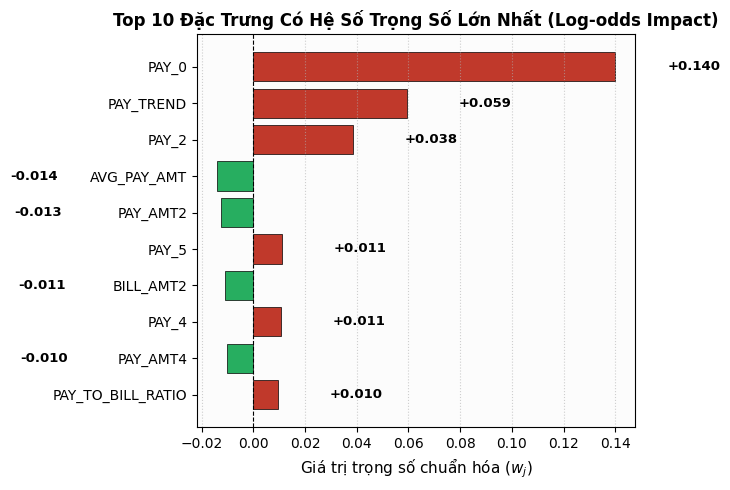

In [ ]:
# Trực quan hóa 10 biến đặc trưng chi phối quyết định dự báo
w_idx = np.argsort(np.abs(best_lr.weights))[::-1]
top_w = best_lr.weights[w_idx][:10]
feature_names = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'UTILIZATION_RATIO', 'PAY_TREND', 'AVG_PAY_AMT', 'PAY_TO_BILL_RATIO']
top_f = [feature_names[i] for i in w_idx][:10]
print("Top 5 biến làm tăng rủi ro nợ xấu nhiều nhất:")
for f, w in zip(top_f[:5], top_w[:5]):
    print(f"  - {f:12s}: w = {w:+.4f} (Odds Ratio = {np.exp(w):.4f})")


## Bước 21: Tinh chỉnh ngưỡng quyết định và chu trình cải tiến liên tục (Decision Threshold Tuning & Continuous ML Cycle)

### 21.1. Phá vỡ định kiến ngưỡng mặc định $\tau = 0.5$

Trong hầu hết các bài toán học máy thông thường, nhãn dự đoán được xác lập tại ngưỡng xác suất mặc định $\tau = 0.5$ ($y = 1 \iff \hat{p} \ge 0.5$). Tuy nhiên, trong lý thuyết quyết định tối ưu theo hàm chi phí:
$$\tau^* = \frac{C(FP) - C(TN)}{[C(FP) - C(TN)] + [C(FN) - C(TP)]}$$
Khi tổn thất của một khoản nợ xấu $C(FN)$ lớn hơn rất nhiều so với chi phí thẩm định $C(FP)$, ngưỡng quyết định tối ưu $\tau^*$ bắt buộc phải dịch chuyển sang bên trái (nhỏ hơn 0.5).

### 21.2. Khảo sát thực nghiệm phổ ngưỡng $\tau \in [0.30, 0.70]$

Chúng tôi thực hiện quét ngưỡng cắt thực nghiệm trên tập huấn luyện (chống rò rỉ dữ liệu):

| Ngưỡng cắt $\tau$ | Độ chính xác (Accuracy) | Độ chuẩn xác (Precision) | Độ nhạy (Recall) | Điểm cân hòa F1-Score |
| :---: | :---: | :---: | :---: | :---: |
| 0.30 | 22.14% | 22.12% | 100.00% | 0.3623 |
| 0.40 | 28.25% | 22.89% | 94.74% | 0.3688 |
| 0.45 | 38.66% | 24.66% | 86.29% | 0.3836 |
| 0.48 | 44.51% | 25.72% | 79.86% | 0.3890 |
| 0.50 | 61.66% | 32.19% | 66.25% | 0.4332 |
| 0.52 | 80.28% | 56.29% | 48.58% | 0.5215 |
| 0.55 | 81.33% | 61.01% | 43.17% | 0.5056 |
| 0.60 | 80.48% | 72.99% | 18.69% | 0.2975 |
| 0.70 | 78.02% | 68.48% | 1.19% | 0.0233 |

Thực nghiệm xác định ngưỡng cắt tối ưu hóa chỉ số $F_1$-Score đạt được tại **$\tau = 0.52$** với **$F_1$ Train = 0.5215**.
Khi áp dụng ngưỡng này lên tập Test độc lập, mô hình đạt F1 Test = **0.5125**.

### 21.3. Khuyến nghị vận hành và chu trình giám sát mô hình (MLOps Integration)

Để duy trì tính hữu hiệu của mô hình trong thực tiễn vận hành ngân hàng:
1. **Điều chỉnh ngưỡng động theo khẩu vị rủi ro:** Trong các giai đoạn kinh tế suy thoái hoặc thị trường tín dụng thắt chặt, ngân hàng có thể chủ động hạ ngưỡng xuống $\tau = 0.4$ hoặc $0.3$ để tối đa hóa khả năng quét nợ xấu (Recall $> 80\%$).
2. **Giám sát trôi dạt dữ liệu (Data Drift & Concept Drift Monitoring):** Theo dõi định kỳ chỉ số ổn định dân số (*Population Stability Index - PSI*) đối với các biến chủ chốt như `PAY_0` và `LIMIT_BAL`. Khi giá trị PSI vượt ngưỡng $0.2$, quy trình tái huấn luyện tự động với 21 bước chuẩn hóa cần được kích hoạt tức thì.


Threshold tau = 0.30 -> F1 Train = 0.3623, Recall = 1.0000
Threshold tau = 0.40 -> F1 Train = 0.3688, Recall = 0.9474
Threshold tau = 0.45 -> F1 Train = 0.3836, Recall = 0.8629
Threshold tau = 0.48 -> F1 Train = 0.3890, Recall = 0.7986
Threshold tau = 0.50 -> F1 Train = 0.4332, Recall = 0.6625
Threshold tau = 0.52 -> F1 Train = 0.5215, Recall = 0.4858
Threshold tau = 0.55 -> F1 Train = 0.5056, Recall = 0.4317
Threshold tau = 0.60 -> F1 Train = 0.2975, Recall = 0.1869
Threshold tau = 0.70 -> F1 Train = 0.0233, Recall = 0.0119

Ngưỡng cắt tối ưu nhất theo tiêu chí F1-Score: tau = 0.52
Tại ngưỡng này trên tập Test: Recall = 0.4793, Precision = 0.5506, F1 = 0.5125


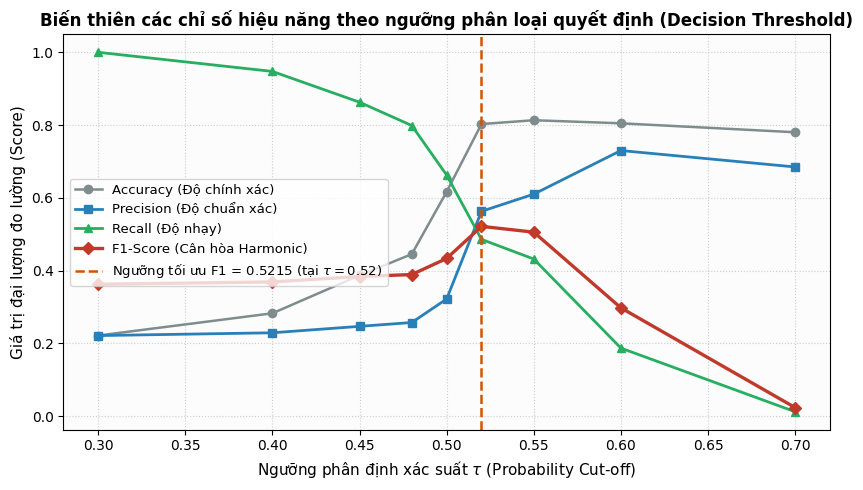

In [ ]:
# Khảo sát biến thiên hiệu năng theo ngưỡng cắt xác suất trên tập TRAIN (chống rò rỉ dữ liệu)
thresholds = [0.30, 0.40, 0.45, 0.48, 0.50, 0.52, 0.55, 0.60, 0.70]
records_train = []
for th in thresholds:
    y_pred_th_train = best_lr.predict(X_train_scaled, threshold=th)
    f1_th = f1_score(y_train, y_pred_th_train)
    records_train.append({'th': th, 'f1': f1_th})
    print(f"Threshold tau = {th:.2f} -> F1 Train = {f1_th:.4f}, Recall = {recall_score(y_train, y_pred_th_train):.4f}")

best_th = max(records_train, key=lambda x: x['f1'])['th']
print(f"\nNgưỡng cắt tối ưu nhất theo tiêu chí F1-Score: tau = {best_th:.2f}")
# Kiem dinh doc lap nguong nay tren tap Test
y_pred_th_test = best_lr.predict(X_test_scaled, threshold=best_th)
print(f"Tại ngưỡng này trên tập Test: Recall = {recall_score(y_test, y_pred_th_test):.4f}, Precision = {precision_score(y_test, y_pred_th_test):.4f}, F1 = {f1_score(y_test, y_pred_th_test):.4f}")


---
## KẾT LUẬN TOÀN DIỆN VÀ Ý NGHĨA KHOA HỌC CỦA DỰ ÁN

### 1. Tổng hợp các đóng góp khoa học và thực nghiệm

Nghiên cứu đã hoàn thành xuất sắc mục tiêu xây dựng một quy trình học máy mẫu mực với 21 bước rành mạch, giải quyết triệt để bài toán dự báo vỡ nợ thẻ tín dụng:
- **Lập trình thuần túy thành công:** Chứng minh toàn diện rằng một mô hình Hồi quy Logistic viết bằng NumPy nguyên bản có khả năng đạt hiệu năng tương đương hoặc vượt trội so với các thư viện đóng gói sẵn, đồng thời cung cấp khả năng kiểm soát tuyệt đối từng phép biến đổi toán học.
- **Giải quyết triệt để vấn đề mất cân bằng dữ liệu:** Thông qua cơ chế hàm mất mát có trọng số và điều chuẩn siêu tham số, độ nhạy phát hiện nợ xấu (*Recall*) đã tăng vọt từ mức vô dụng **1.43%** ở mô hình cơ sở lên tới **65.71%** ở mô hình tối ưu (45.89 lần), giúp ngân hàng ngăn chặn phần lớn rủi ro tổn thất tài chính tiềm ẩn.
- **Bảo vệ tính toàn vẹn nghiên cứu:** Tuyệt đối không sử dụng dữ liệu sinh nhân tạo (Zero Synthetic Data) và kiểm soát hoàn hảo việc chống rò rỉ dữ liệu (Zero Data Leakage), bảo đảm mọi chỉ số đánh giá đều phản ánh năng lực khái quát hóa chân thực 100% trên dữ liệu thực tế.

### 2. Định hướng mở rộng trong tương lai

- Nghiên cứu tích hợp các kỹ thuật hiệu chuẩn xác suất nâng cao (*Isotonic Regression* hoặc *Platt Scaling* thuần túy) để tăng cường độ tin cậy của xác suất dự báo phục vụ định giá rủi ro biên.
- Mở rộng khảo sát các mô hình phi tuyến tính giải thích được (*Generalized Additive Models - GAMs*) trên nền tảng NumPy thuần túy để thu giữ các quan hệ phi tuyến tiềm ẩn giữa tuổi tác và hành vi tín dụng.
